**Introduction & Setup**

**The Goal**

We are building an AI model to predict if a user will buy a product again (reorder).


**The Challenge:**

 The dataset is massive (millions of rows). If we just try to load and merge everything, Google Colab will run out of memory (RAM) and crash.


**The Solution:**

 We will use smart data engineering: downloading via kagglehub, sampling a subset of users, and using chunking to process the large files.

**Data Acquisition**

In [ ]:
# Step 1: Install and import kagglehub to download the dataset directly into Colab
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/instacart-online-grocery-basket-analysis-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'instacart-online-grocery-basket-analysis-dataset' dataset.
Path to dataset files: /kaggle/input/instacart-online-grocery-basket-analysis-dataset


**Task 1 - Primary Key / Foreign Key Relationships**

Explain how these tables are related (primary key–foreign key relationships):

     orders.csv: order_id is the Primary Key. user_id is a Foreign Key linking to a theoretical users table.
     order_products__prior.csv: This is a bridging/junction table. It has a composite Primary Key of (order_id, product_id). order_id is a Foreign Key referencing orders.csv. product_id is a Foreign Key referencing products.csv.
     products.csv: product_id is the Primary Key. aisle_id and department_id are Foreign Keys referencing aisles.csv and departments.csv respectively.
     aisles.csv & departments.csv: aisle_id and department_id are their respective Primary Keys.
     

**Exploring the Downloaded Data**

In [ ]:
import os
import pandas as pd

print("Files in the dataset directory:")
for file in os.listdir(path):
    print(f" - {file}")

Files in the dataset directory:
 - products.csv
 - order_products__train.csv
 - orders.csv
 - order_products__prior.csv
 - aisles.csv
 - departments.csv


In [ ]:
import pandas as pd

# Load the orders file
df_orders = pd.read_csv(os.path.join(path, 'orders.csv'))

# 1. Enable interactive tables (Recommended for Colab)
from google.colab import data_table
data_table.enable_dataframe_formatter()

# 2. Display the dataframe
df_orders


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0
...,...,...,...,...,...,...,...
3421078,2266710,206209,prior,10,5,18,29.0
3421079,1854736,206209,prior,11,4,10,30.0
3421080,626363,206209,prior,12,1,12,18.0
3421081,2977660,206209,prior,13,1,12,7.0


**Data Understanding & Integration**

In [ ]:
pd.read_csv(os.path.join(path, 'orders.csv')).head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [ ]:
pd.read_csv(os.path.join(path, 'products.csv')).head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [ ]:
pd.read_csv(os.path.join(path, 'aisles.csv')).head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [ ]:
pd.read_csv(os.path.join(path, 'departments.csv')).head()

,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


**Task 1 - Data Understanding**



     orders.csv: The When and Who. (Has order_id, user_id, time).
     order_products__prior.csv: The What. (Which product_id went into which order_id). This is the massive file.
     products.csv: The Details. (Name of the product_id).
     aisles.csv & departments.csv: The Categories.
     

Relationships: Think of them as a chain: Order -> connects to -> Order_Product -> connects to -> Product -> connects to -> Aisle/Department. The connection points are the IDs (Primary and Foreign keys).

**` Loading the Base Tables`**

In [ ]:
orders_path = os.path.join(path, 'orders.csv')
products_path = os.path.join(path, 'products.csv')
aisles_path = os.path.join(path, 'aisles.csv')
departments_path = os.path.join(path, 'departments.csv')

In [ ]:

# Load into pandas DataFrames
df_orders = pd.read_csv(orders_path)
df_products = pd.read_csv(products_path)
df_aisles = pd.read_csv(aisles_path)
df_departments = pd.read_csv(departments_path)

In [ ]:
# Quick look at the Orders table
print("Orders Table Shape:", df_orders.shape)
df_orders.head()

Orders Table Shape: (3421083, 7)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


**The Memory Constraint Strategy**

The order_products__prior.csv file has over 30 million rows. Loading it directly takes ~1.5GB of RAM. Merging it with other tables multiplies the memory required, leading to a crash.
Our Strategy:

    Filter First: Pick exactly 10,000 random users from orders.csv.
    Chunking: Read the massive 30M row file in small "chunks" (e.g., 500,000 rows at a time).
    Discard: Keep only the rows in the chunk that belong to our 10,000 users. Throw the rest away immediately to free up memory.



 Executing the Sampling & Chunking Strategy (Bonus Task)

In [ ]:
import gc # Garbage collector - helps free up RAM

# 1. Get 10,000 random users
sample_users = df_orders['user_id'].drop_duplicates().sample(n=10000, random_state=42)
df_orders_sample = df_orders[df_orders['user_id'].isin(sample_users)]

# Get the list of order IDs belonging to these users
valid_order_ids = df_orders_sample['order_id'].unique()

# 2. Find the exact filename for the prior orders (sometimes it has double underscores)
prior_file = [f for f in os.listdir(path) if 'prior' in f][0]
prior_path = os.path.join(path, prior_file)

# 3. Chunking loop
chunks = []
chunk_size = 500000

print(f"Processing {prior_file} in chunks...")
for chunk in pd.read_csv(prior_path, chunksize=chunk_size):
    # Keep ONLY the rows where the order_id is in our sampled user list
    filtered_chunk = chunk[chunk['order_id'].isin(valid_order_ids)]

    if not filtered_chunk.empty:
        chunks.append(filtered_chunk)

    # Delete the raw chunk to free memory immediately!
    del chunk
    gc.collect()

# Combine our saved chunks into one dataframe
df_prior = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

print(f"Success! Reduced 30 Million rows down to: {len(df_prior)} rows for our sample.")

Processing order_products__prior.csv in chunks...
Success! Reduced 30 Million rows down to: 1578962 rows for our sample.


**Task 2 - Merging the Master Dataset**

In [ ]:
# merge on the "Bridge" columns (order_id, product_id, aisle_id, department_id)

# Merge Prior Orders with Orders (to get user behavior data)
master_df = pd.merge(df_prior, df_orders_sample, on='order_id', how='left')

# Merge with Products
master_df = pd.merge(master_df, df_products, on='product_id', how='left')

# Merge with Aisles and Departments
master_df = pd.merge(master_df, df_aisles, on='aisle_id', how='left')
master_df = pd.merge(master_df, df_departments, on='department_id', how='left')

# Clean up intermediate dataframes
del df_prior, df_orders_sample
gc.collect()

print("Final Master Dataset Shape:", master_df.shape)
master_df.head(3)

Final Master Dataset Shape: (1578962, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,28,35108,1,0,98256,prior,29,3,13,6.0,Salted Butter,36,16,butter,dairy eggs
1,28,40593,2,1,98256,prior,29,3,13,6.0,Cream Cheese,108,16,other creams cheeses,dairy eggs
2,28,17461,3,0,98256,prior,29,3,13,6.0,Air Chilled Organic Boneless Skinless Chicken ...,35,12,poultry counter,meat seafood


**Task 3 - Handling Missing Data**

**` days_since_prior_order: `**

 This is NaN only when it is the user's very first order (because there is no prior order!). It makes logical sense to fill this with 0.


`** reordered:**`

  If missing, we assume it's 0 (not a reorder).

**Task 3 - Cleaning**

In [ ]:
# Check missing values
print("Missing values before cleaning:")
print(master_df[['days_since_prior_order', 'reordered']].isnull().sum())

# Fill missing values safely
master_df['days_since_prior_order'] = master_df['days_since_prior_order'].fillna(0)
master_df['reordered'] = master_df['reordered'].fillna(0)

# Drop any accidental duplicates
master_df = master_df.drop_duplicates(subset=['order_id', 'product_id'])

print("\nMissing values after cleaning: 0")

Missing values before cleaning:
days_since_prior_order    100799
reordered                      0
dtype: int64

Missing values after cleaning: 0


**Task 4 & 5 - Feature Engineering**

In [ ]:
# 1. User-Product level (Habit)
user_prod_feat = master_df.groupby(['user_id', 'product_id']).agg(
    times_user_bought_product=('order_id', 'count')
).reset_index()

# 2. Product level (Popularity)
product_feat = master_df.groupby('product_id').agg(
    total_times_bought_globally=('order_id', 'count')
).reset_index()

# 3. User level (Habits)
user_feat = master_df.groupby('user_id').agg(
    user_total_orders=('order_id', 'nunique'),
    user_total_items=('product_id', 'count')
).reset_index()
user_feat['user_avg_basket_size'] = user_feat['user_total_items'] / user_feat['user_total_orders']

# Merge these new features back into our master dataframe
master_df = pd.merge(master_df, user_prod_feat, on=['user_id', 'product_id'], how='left')
master_df = pd.merge(master_df, product_feat, on='product_id', how='left')
master_df = pd.merge(master_df, user_feat, on='user_id', how='left')

# 4. Time Features
# 0 and 1 are Saturday/Sunday in Instacart data
master_df['is_weekend'] = master_df['order_dow'].apply(lambda x: 1 if x in [0, 1] else 0)

def time_of_day(hour):
    if 5 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else: return 'Night'

master_df['time_period'] = master_df['order_hour_of_day'].apply(time_of_day)

**Task 6 - Encoding Categorical Data Encoding**

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoders
le_aisle = LabelEncoder()
le_dept = LabelEncoder()
le_time = LabelEncoder()

# Transform text to numbers
master_df['aisle_encoded'] = le_aisle.fit_transform(master_df['aisle'])
master_df['department_encoded'] = le_dept.fit_transform(master_df['department'])
master_df['time_encoded'] = le_time.fit_transform(master_df['time_period'])

# Drop the text columns, we don't need them anymore
master_df = master_df.drop(columns=['aisle', 'department', 'time_period', 'product_name', 'eval_set'])

**Task 7 - EDA  Visualizations**

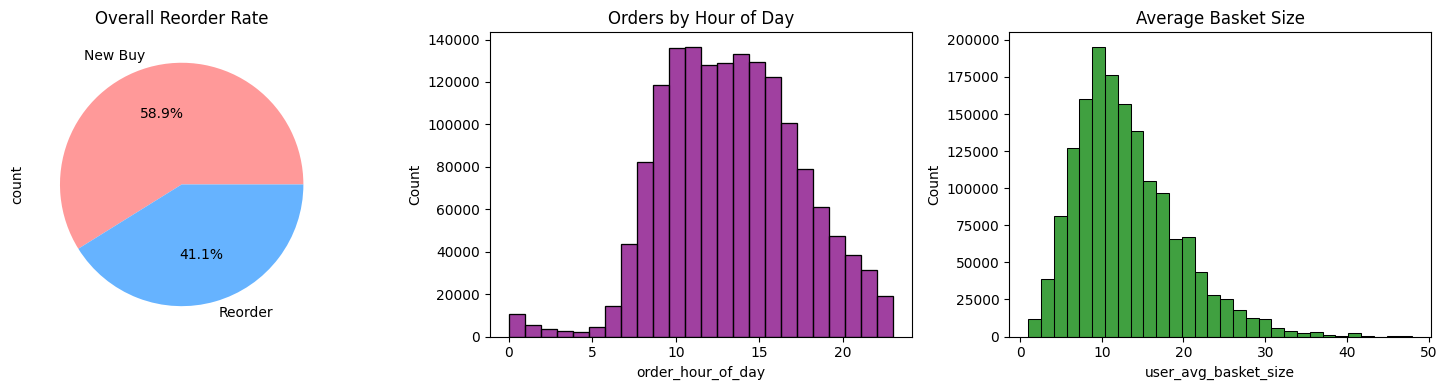

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 4))

# 1. Reorder Distribution
plt.subplot(1, 3, 1)
master_df['reordered'].value_counts().plot(kind='pie', labels=['New Buy', 'Reorder'], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Overall Reorder Rate')

# 2. Peak Hours
plt.subplot(1, 3, 2)
sns.histplot(master_df['order_hour_of_day'], bins=24, color='purple')
plt.title('Orders by Hour of Day')

# 3. User Avg Basket Size Distribution
plt.subplot(1, 3, 3)
sns.histplot(master_df['user_avg_basket_size'], bins=30, color='green')
plt.title('Average Basket Size')

plt.tight_layout()
plt.show()

**Markdown Cell 8: Task 8 & 9 - Modeling and Evaluation**

We will use a Random Forest. It's great for this because it naturally handles non-linear relationships (e.g., "Buying milk at 9 AM means a reorder, but buying beer at 9 AM doesn't").
Why not Accuracy? If 59% of items are reorders, a lazy model that just guesses "Reorder" every single time gets 59% Accuracy. That's a useless model. We need Precision (when we say it's a reorder, are we right?) and Recall (did we catch all the reorders?).

**10: Modeling & Evaluation**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Define our X (Clues) and y (Target we want to predict)
feature_cols = [
    'order_number', 'days_since_prior_order', 'is_weekend',
    'times_user_bought_product', 'total_times_bought_globally',
    'user_total_orders', 'user_avg_basket_size',
    'aisle_encoded', 'department_encoded', 'time_encoded'
]

X = master_df[feature_cols]
y = master_df['reordered']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model (using limited trees/depth so Colab finishes in a minute)
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

# Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Random Forest...

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.76      0.85    129830
           1       0.85      0.98      0.91    185963

    accuracy                           0.89    315793
   macro avg       0.91      0.87      0.88    315793
weighted avg       0.90      0.89      0.89    315793



**Markdown Cell 9: Task 10 - Deployment in the Real World**



How does this code become a real app feature?
When a user opens the Instacart app, the backend system triggers an API.
Crucial step: The backend must mathematically recreate the exact same features we created here in real-time:

    It queries the database: "How many times did User 123 buy Bananas?" -> times_user_bought_product
    It checks the clock: "Is it Sunday?" -> is_weekend
    It looks up the item: "What aisle is this?" -> aisle_encoded
    It compiles these into a single row of numbers, feeds it to the trained Random Forest model, and if the output probability is > 0.5, the app puts a little "Buy it again?" badge next to the Banana.